Signal Names: ['ax', 'ay', 'az', 'temp', 'EDA', 'SpO2', 'hr']
         ax       ay        az       temp       EDA       SpO2         hr
0  0.760015 -0.86999 -0.100004  30.100043  0.083039  96.999969  89.000763
1  0.770025 -0.86999 -0.110031  30.100043  0.081028  96.999969  88.000137
2  0.750005 -0.86999 -0.100004  30.100043  0.081028  96.999969  87.000443
3  0.770025 -0.86999 -0.100004  30.100043  0.079018  96.999969  87.000443
4  0.750005 -0.86999 -0.100004  30.100043  0.081028  96.999969  87.000443
                 ax            ay            az          temp           EDA  \
count  18343.000000  18343.000000  18343.000000  18343.000000  18343.000000   
mean       0.434065     -0.852649     -0.259663     32.677343      0.571436   
std        0.319034      0.246875      0.310943      0.665554      0.535153   
min       -0.549953     -1.819960     -1.919962     30.100043      0.079018   
25%        0.200001     -1.039995     -0.400017     32.399966      0.130000   
50%        0.390043 

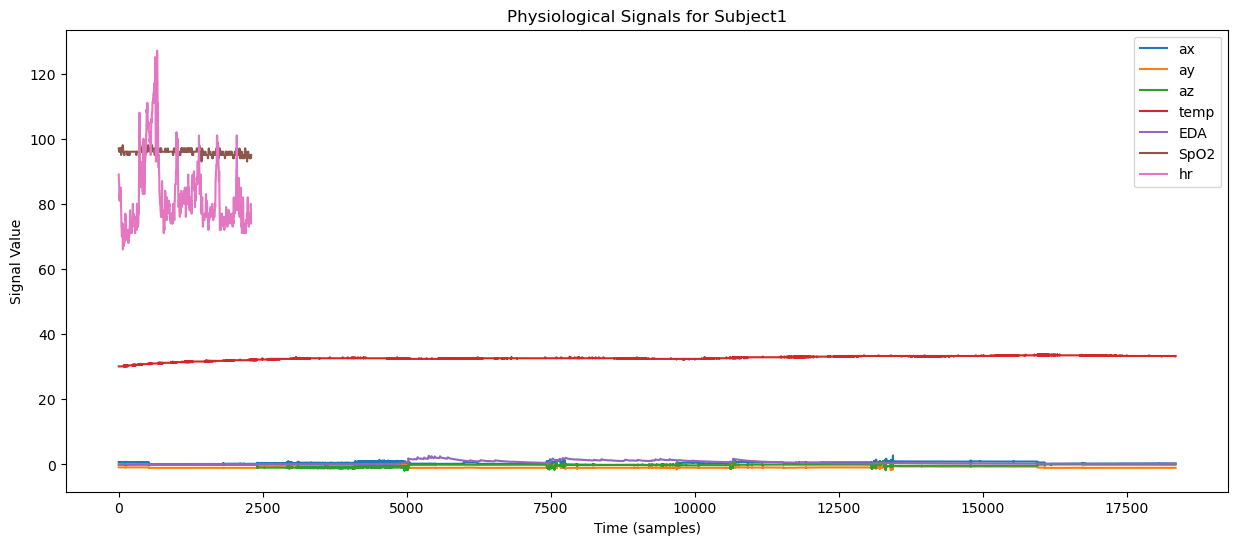

In [5]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the dataset folder path
dataset_path = "C:/Users/Asus/Desktop/EEG"

# Choose a subject (e.g., Subject 1)
subject_id = "Subject1"
acc_file = os.path.join(dataset_path, f"{subject_id}_AccTempEDA")
spo2_file = os.path.join(dataset_path, f"{subject_id}_SpO2HR")

# Load AccTempEDA signals
record_acc = wfdb.rdrecord(acc_file)
df_acc = pd.DataFrame(record_acc.p_signal, columns=record_acc.sig_name)

# Load SpO2HR signals
record_spo2 = wfdb.rdrecord(spo2_file)
df_spo2 = pd.DataFrame(record_spo2.p_signal, columns=record_spo2.sig_name)

# Combine both dataframes
df = pd.concat([df_acc, df_spo2], axis=1)

# Display data info
print("Signal Names:", df.columns.tolist())
print(df.head())

# Summary Statistics
print(df.describe())

# Plot all signals
plt.figure(figsize=(15, 6))
for col in df.columns:
    plt.plot(df[col], label=col)

plt.xlabel("Time (samples)")
plt.ylabel("Signal Value")
plt.title(f"Physiological Signals for {subject_id}")
plt.legend()
plt.show()


In [6]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

# Function to extract features from a signal
def extract_features(df):
    features = {}
    
    for col in df.columns:
        signal = df[col].dropna()  # Drop NaN values
        
        # Time-domain features
        features[f"{col}_mean"] = np.mean(signal)
        features[f"{col}_std"] = np.std(signal)
        features[f"{col}_min"] = np.min(signal)
        features[f"{col}_max"] = np.max(signal)
        features[f"{col}_skew"] = skew(signal)
        features[f"{col}_kurtosis"] = kurtosis(signal)
        
        # Frequency-domain features (Power Spectral Density)
        f, Pxx = welch(signal, fs=100, nperseg=256)  # Assume 100Hz sampling rate
        features[f"{col}_psd_mean"] = np.mean(Pxx)
        features[f"{col}_psd_max"] = np.max(Pxx)
    
    return pd.DataFrame([features])

# Extract features for Subject 1
features_df = extract_features(df)

# Display extracted features
print(features_df)



    ax_mean    ax_std    ax_min    ax_max   ax_skew  ax_kurtosis  ax_psd_mean  \
0  0.434065  0.319025 -0.549953  2.779997  0.087498    -0.638049      0.00019   

   ax_psd_max   ay_mean    ay_std  ...  SpO2_psd_mean  SpO2_psd_max  \
0    0.006879 -0.852649  0.246868  ...       0.010822      0.261168   

     hr_mean     hr_std     hr_min      hr_max   hr_skew  hr_kurtosis  \
0  82.152551  10.663493  66.000336  126.999405  1.569089     2.370717   

   hr_psd_mean  hr_psd_max  
0     0.899302   41.330626  

[1 rows x 56 columns]


In [7]:
import glob

# List all subject files (AccTempEDA only, to avoid duplicates)
subject_files = glob.glob(f"{dataset_path}/*_AccTempEDA.hea")

# Initialize feature storage
all_features = []

for file in subject_files:
    subject_id = os.path.basename(file).split("_")[0]  # Extract Subject ID
    
    # Load signals
    acc_file = os.path.join(dataset_path, f"{subject_id}_AccTempEDA")
    spo2_file = os.path.join(dataset_path, f"{subject_id}_SpO2HR")

    record_acc = wfdb.rdrecord(acc_file)
    df_acc = pd.DataFrame(record_acc.p_signal, columns=record_acc.sig_name)

    record_spo2 = wfdb.rdrecord(spo2_file)
    df_spo2 = pd.DataFrame(record_spo2.p_signal, columns=record_spo2.sig_name)

    df = pd.concat([df_acc, df_spo2], axis=1)

    # Extract features
    features = extract_features(df)
    features["subject"] = subject_id  # Add subject ID for tracking
    all_features.append(features)

# Create final DataFrame
features_df = pd.concat(all_features, ignore_index=True)

print("Feature Extraction Complete!")
print(features_df.head())


Feature Extraction Complete!
    ax_mean    ax_std    ax_min    ax_max   ax_skew  ax_kurtosis  ax_psd_mean  \
0  0.692899  0.365204 -0.739971  1.619993 -0.679533    -0.434261     0.000332   
1  0.660368  0.266570 -0.579965  2.319991 -0.707609    -0.286587     0.000201   
2  0.485312  0.444412 -1.359955  1.749998 -1.047151     0.034885     0.000247   
3  0.653943  0.318371 -0.789974  1.549990 -0.340421    -0.292476     0.000497   
4  0.238961  0.291650 -0.689979  1.849982 -0.689526    -0.428214     0.000119   

   ax_psd_max   ay_mean    ay_std  ...  SpO2_psd_max    hr_mean     hr_std  \
0    0.013343 -0.624442  0.259935  ...      0.216093  78.452998  11.075850   
1    0.007500 -0.758372  0.249834  ...      0.223987  80.498842  10.452996   
2    0.009302 -0.765113  0.223419  ...      0.393918  67.709703  12.232145   
3    0.019637 -0.729185  0.250293  ...      0.352444  75.684034  13.311313   
4    0.004840 -0.884885  0.201860  ...      0.563153  68.877024  11.429059   

      hr_min   

In [8]:
# Define binary labels based on HR and EDA
features_df["label"] = ((features_df["hr_mean"] > 90) | (features_df["EDA_mean"] > 1.5)).astype(int)

print(features_df[["hr_mean", "EDA_mean", "label"]].head())


     hr_mean  EDA_mean  label
0  78.452998  7.020280      1
1  80.498842  2.250043      1
2  67.709703  3.296290      1
3  75.684034  1.360362      0
4  68.877024  0.631012      0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare dataset
X = features_df.drop(columns=["subject", "label"])  # Features
y = features_df["label"]  # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



XGBoost Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



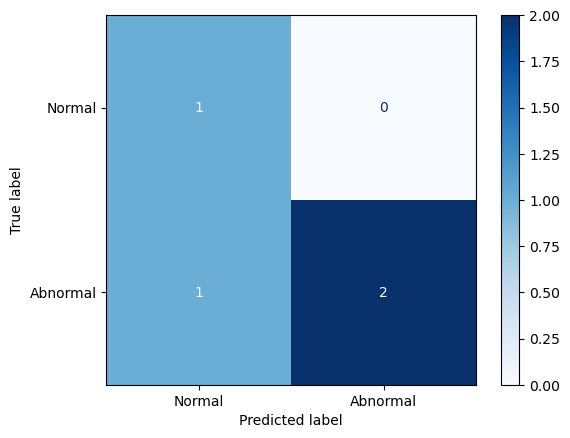

In [10]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=3, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
disp.plot(cmap="Blues")
plt.show()


Random Forest Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



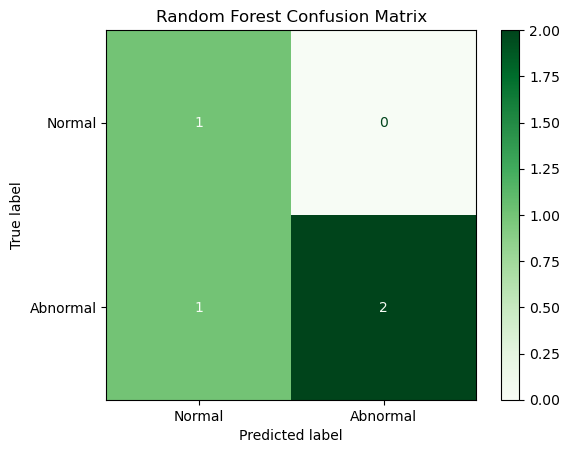

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Abnormal"])
disp_rf.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()
